Dictionary keys: dict_keys(['bins', 'values'])
Number of bin edges: 251
Number of count values: 250
Total expected counts (before rescaling) = 199326.21
Total actual counts = 200310
Total expected counts (after rescaling) = 200310.00


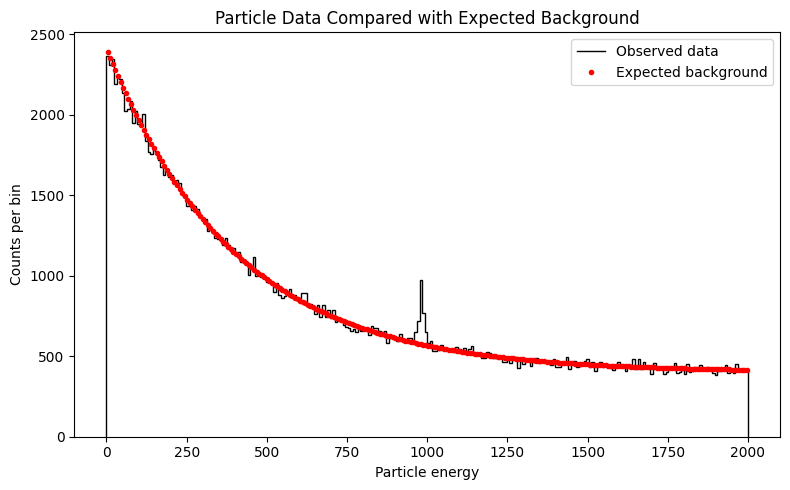

Chi-Square Statistic: 617.134
Reduced Chi-Square: 2.478
P-value: 0.000
Degrees of freedom: 249


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# Load the particle data dictionary
particle_data = np.load("particle_data.npy", allow_pickle=True).item()

# Check available keys
print("Dictionary keys:", particle_data.keys())

# Extract bin edges and observed counts
bin_edges = np.array(particle_data["bins"])
count_values = np.array(particle_data["values"])

print("Number of bin edges:", len(bin_edges))
print("Number of count values:", len(count_values))

# Define the expected background model integrated over each bin
def bin_prob_unnorm(x_min, x_max, A, B, C):
    """
    Returns the expected number of background events in a bin [x_min, x_max]
    using the unnormalised model provided.
    """
    return B * A * (np.exp(-x_min / B) - np.exp(-x_max / B)) + C * (x_max - x_min)

# Model parameters
A = 250
B = 400
C = 50

# Calculate expected counts in each bin
expected_values = np.array([
    bin_prob_unnorm(bin_edges[i - 1], bin_edges[i], A, B, C)
    for i in range(1, len(bin_edges))
])

# Compare totals before rescaling
total_expected = expected_values.sum()
total_counts = count_values.sum()

print(f"Total expected counts (before rescaling) = {total_expected:.2f}")
print(f"Total actual counts = {total_counts}")

# Rescale expected counts so total matches observed counts
expected_values = expected_values * (total_counts / total_expected)

print(f"Total expected counts (after rescaling) = {expected_values.sum():.2f}")

# Plot observed data and expected background
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8, 5))
plt.stairs(count_values, bin_edges, label="Observed data", color="black")
plt.plot(bin_centres, expected_values, "o", color="red", markersize=3, label="Expected background")
plt.xlabel("Particle energy")
plt.ylabel("Counts per bin")
plt.title("Particle Data Compared with Expected Background")
plt.legend()
plt.tight_layout()
plt.show()

# Perform Pearson chi-squared goodness-of-fit test
chi2_result = chisquare(f_obs=count_values, f_exp=expected_values)

# Degrees of freedom:
# number of bins - 1
dof = len(count_values) - 1

# Reduced chi-squared
reduced_chi2 = chi2_result.statistic / dof

# Print results
print(f"Chi-Square Statistic: {chi2_result.statistic:.3f}")
print(f"Reduced Chi-Square: {reduced_chi2:.3f}")
print(f"P-value: {chi2_result.pvalue:.3f}")
print(f"Degrees of freedom: {dof}")